TEST NOTEBOOK BEFORE COPYING OVER SUPERHOST MODel FROM Local MACHINE

In [170]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix
from sklearn.preprocessing import OrdinalEncoder
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import mutual_info_classif



## STEP 1: Data Understanding: view and understand what our data is.

In [171]:
#shape of data
filename = os.path.join(os.getcwd(), "../data", "nyclistings.csv")
df = pd.read_csv(filename,header=0)
df.shape

(30234, 90)

In [172]:
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2539,https://www.airbnb.com/rooms/2539,20260810212434,2026-08-11,city scrape,11 Min to Manhattan • Prospect Park • Fast WiFi,"Bright, serene room in a renovated apartment h...",NaN,https://a0.muscache.com/pictures/hosting/Hosti...,2787,...,5.00,4.78,4.78,NaN,NaN,3,0,3,0,0.08
1,6848,https://www.airbnb.com/rooms/6848,20260810212434,2026-08-11,city scrape,Only 2 stops to Manhattan studio,Comfortable studio apartment with super comfor...,NaN,https://a0.muscache.com/pictures/e4f031a7-f146...,15991,...,4.80,4.70,4.59,NaN,NaN,1,1,0,0,0.95
2,6872,https://www.airbnb.com/rooms/6872,20260810212434,2026-08-11,city scrape,Uptown Sanctuary w/ Private Bath (Month to Month),This charming month-to-month home away from ho...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,16104,...,5.00,5.00,5.00,NaN,NaN,2,0,2,0,0.04
3,146726,https://www.airbnb.com/rooms/146726,20260810212434,2026-08-11,city scrape,Cozy authentic residence near Central Park,We are back - renovated and better! <br />Only...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,709334,...,4.94,4.56,4.72,NaN,NaN,1,1,0,0,0.10
4,148201,https://www.airbnb.com/rooms/148201,20260810212434,2026-08-11,previous scrape,NYC - Sunny Greenwich Village 1br,Due to the current NYC Airbnb laws - specifica...,NaN,https://a0.muscache.com/pictures/937604/f87860...,715807,...,4.88,4.88,4.81,NaN,NaN,1,1,0,0,0.10


In [173]:
df.describe()
#we have alot of null values at first glance and columns with litte predictuve value like id, and urls.

,id,scrape_id,neighborhood_overview,host_id,host_profile_id,host_since,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
count,3.023400e+04,3.023400e+04,0.0,3.023400e+04,2.967100e+04,0.0,29671.000000,29671.000000,29671.000000,29671.000000,...,21917.000000,21922.000000,21916.000000,21916.000000,0.0,30234.000000,30234.000000,30234.000000,30234.000000,21925.000000
mean,6.363009e+17,2.026081e+13,NaN,1.004816e+16,1.471941e+18,NaN,8.421725,5.286509,6.798760,5.393650,...,4.833656,4.815979,4.743830,4.627536,NaN,52.350466,43.137263,8.199047,0.060131,0.918840
std,6.273967e+17,3.906315e-03,NaN,1.305816e+17,3.405743e+16,NaN,4.008837,3.461519,3.930537,3.403809,...,0.388946,0.431942,0.395915,0.505979,NaN,162.804024,161.169842,33.665336,0.731392,2.336176
min,2.539000e+03,2.026081e+13,NaN,1.678000e+03,1.462506e+18,NaN,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,NaN,1.000000,0.000000,0.000000,0.000000,0.010000
25%,3.057865e+07,2.026081e+13,NaN,2.085777e+07,1.462881e+18,NaN,5.000000,2.000000,3.000000,2.000000,...,4.820000,4.810000,4.670000,4.520000,NaN,1.000000,0.000000,0.000000,0.000000,0.090000
50%,6.776256e+17,2.026081e+13,NaN,1.074344e+08,1.465525e+18,NaN,9.000000,5.000000,7.000000,6.000000,...,4.950000,4.960000,4.850000,4.750000,NaN,2.000000,1.000000,0.000000,0.000000,0.270000
75%,1.174801e+18,2.026081e+13,NaN,4.021871e+08,1.469613e+18,NaN,11.000000,8.000000,10.000000,8.000000,...,5.000000,5.000000,5.000000,4.920000,NaN,12.000000,3.000000,2.000000,0.000000,0.990000
max,1.748741e+18,2.026081e+13,NaN,1.748739e+18,1.748741e+18,NaN,18.000000,11.000000,15.000000,11.000000,...,5.000000,5.000000,5.000000,5.000000,NaN,908.000000,908.000000,231.000000,16.000000,115.860000


In [174]:
#features in the dataset
columns = list(df.columns)
columns 

['id',
 'listing_url',
 'scrape_id',
 'last_scraped',
 'source',
 'name',
 'description',
 'neighborhood_overview',
 'picture_url',
 'host_id',
 'host_url',
 'host_profile_id',
 'host_profile_url',
 'host_name',
 'host_since',
 'hosts_time_as_user_years',
 'hosts_time_as_user_months',
 'hosts_time_as_host_years',
 'hosts_time_as_host_months',
 'host_location',
 'host_about',
 'host_response_time',
 'host_response_rate',
 'host_acceptance_rate',
 'host_is_superhost',
 'host_thumbnail_url',
 'host_picture_url',
 'host_neighbourhood',
 'host_listings_count',
 'host_total_listings_count',
 'host_verifications',
 'host_has_profile_pic',
 'host_identity_verified',
 'neighbourhood',
 'neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'latitude',
 'longitude',
 'property_type',
 'room_type',
 'accommodates',
 'bathrooms',
 'bathrooms_text',
 'bedrooms',
 'beds',
 'amenities',
 'price',
 'price_quote_checkin_date',
 'price_quote_checkout_date',
 'price_quote_total_price',
 'price_quote

In [175]:
#number of unqiue values for each column
df.nunique()

id                                              30234
listing_url                                     30234
scrape_id                                           1
last_scraped                                        3
source                                              2
                                                ...  
calculated_host_listings_count                     68
calculated_host_listings_count_entire_homes        52
calculated_host_listings_count_private_rooms       40
calculated_host_listings_count_shared_rooms         9
reviews_per_month                                 846
Length: 90, dtype: int64

In [176]:
#drop columns that are completely null with no data: early drop before going into data cleaning
fully_null = df.columns[df.isnull().all()].tolist()
df.drop(fully_null,axis=1,inplace=True)

## View distribution of data to get a sense of the shape of the data for filling in missing values.

if the data is normally distrubuted its best to use the mean as our center however if the data is skewed, it's better to use our median as the center and fill missing values with that instead.
Reasoning: For normal istrubutions data is symetric so the data is balaced on each side. For skewed data outliers pull the mean away from the true center value.

saved 00a


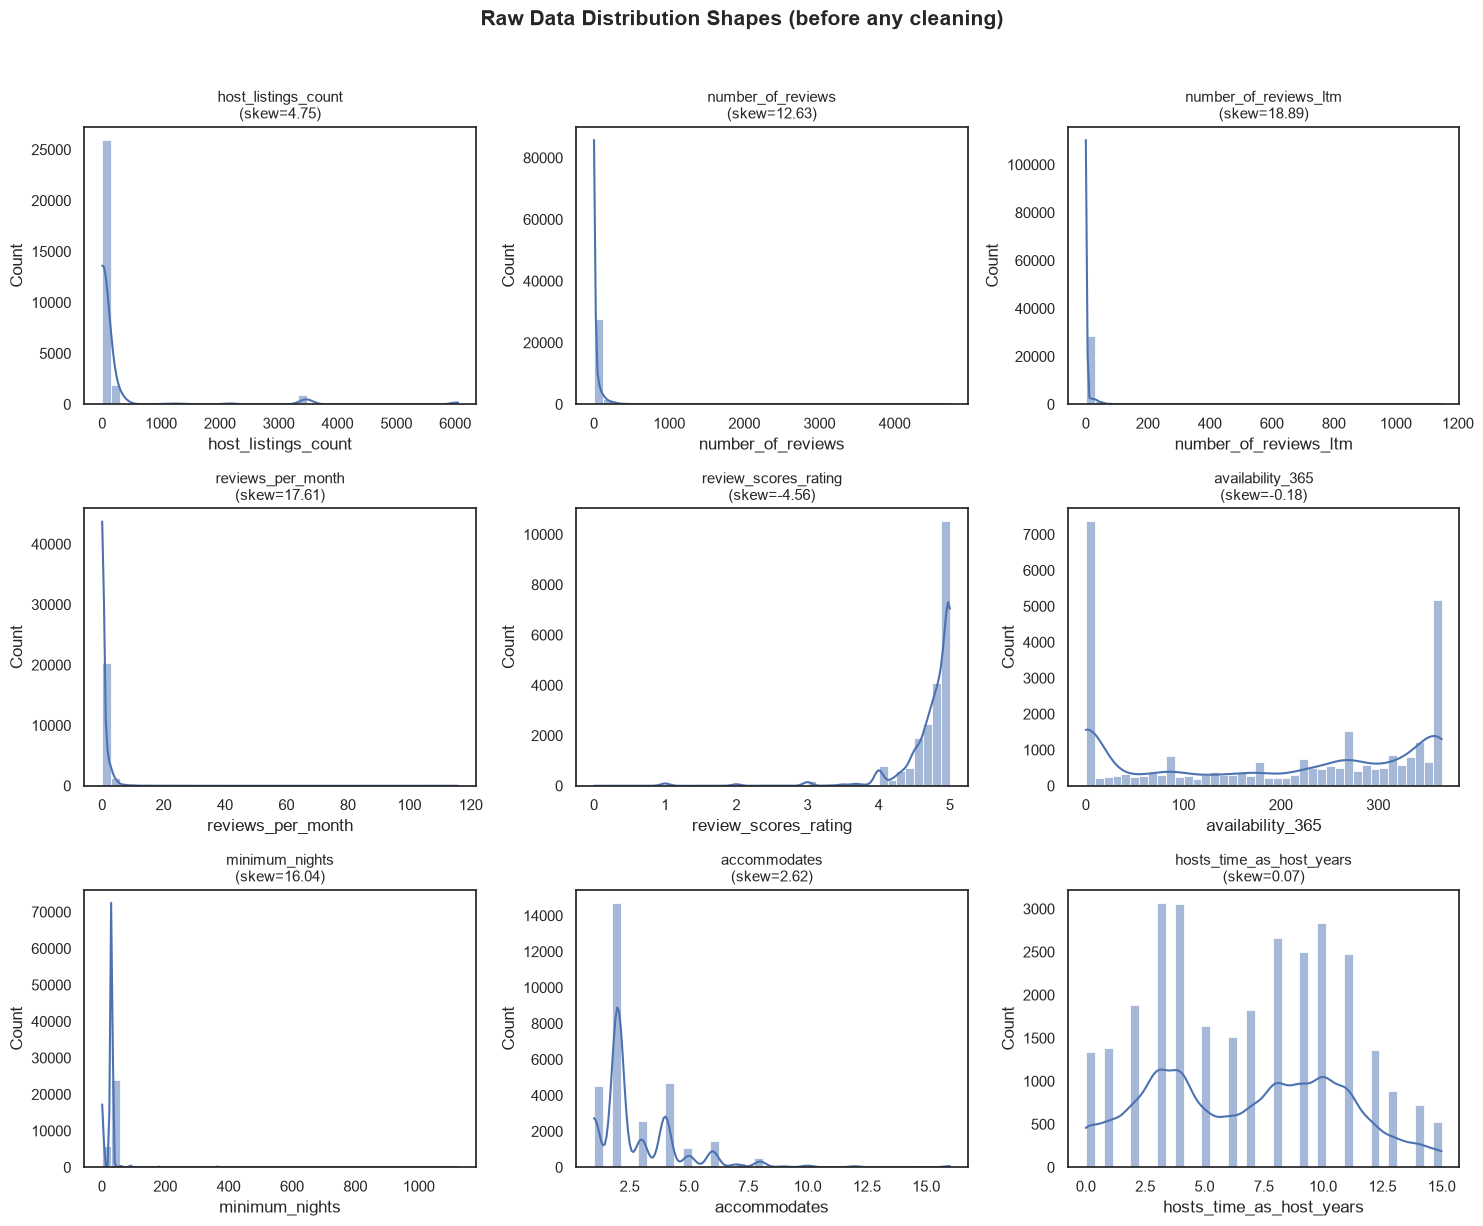

In [177]:
#plot data: of subset of numerical columns: we have alot of numerical columns so only plot a few
raw_numeric_candidates = [
    'host_listings_count', 'number_of_reviews', 'number_of_reviews_ltm',
    'reviews_per_month', 'review_scores_rating', 'availability_365',
    'minimum_nights', 'accommodates', 'hosts_time_as_host_years'
]

fig, axes = plt.subplots(3, 3, figsize=(15, 12))
axes = axes.flatten()
for i, col in enumerate(raw_numeric_candidates):
    data = df[col].dropna()
    sns.histplot(data, bins=40, kde=True, ax=axes[i], color='#4C72B0')
    axes[i].set_title(f"{col}\n(skew={data.skew():.2f})", fontsize=11)
plt.suptitle('Raw Data Distribution Shapes (before any cleaning)', fontsize=15, fontweight='bold', y=1.02)
plt.tight_layout()
print("saved 00a")

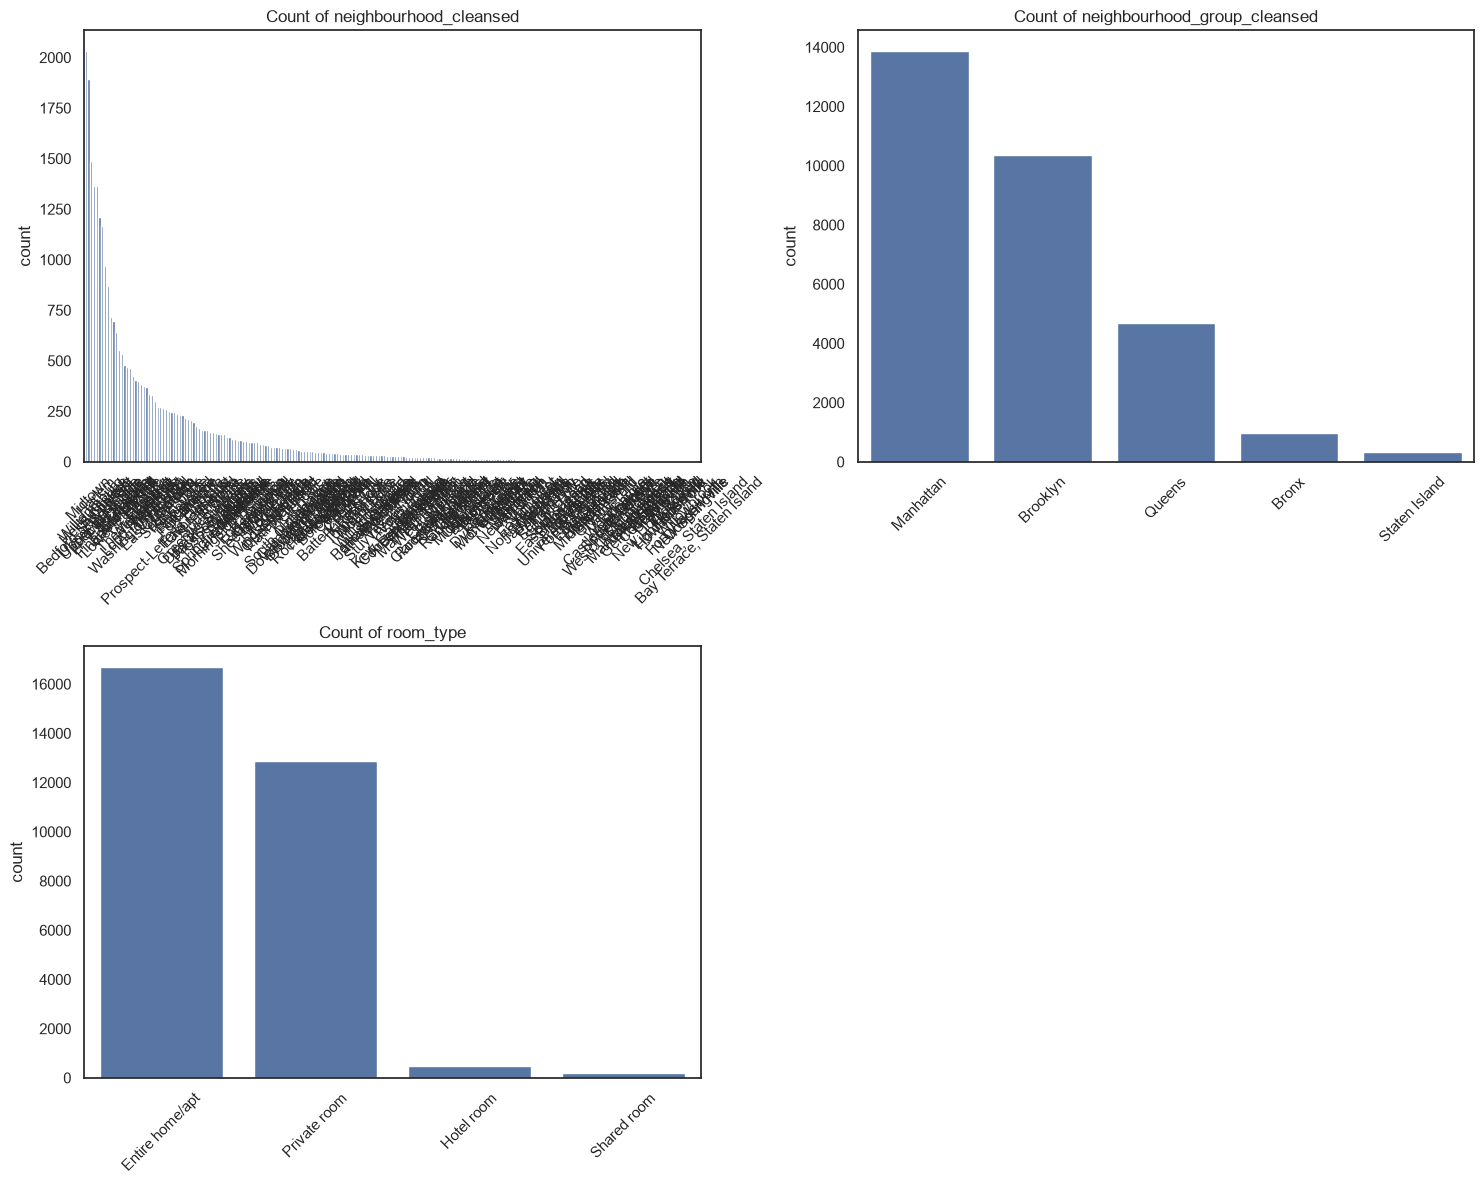

In [178]:
#Only plotting afew since we have alot of columns which would crash the kernel
categorical_cols = ["neighbourhood_cleansed", "neighbourhood_group_cleansed", "room_type"]



fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten() # Flatten the array to loop easily

# 4. Loop through each categorical column and plot counts
for i, col in enumerate(categorical_cols):
    sns.countplot(data=df, x=col, ax=axes[i], order=df[col].value_counts().index)
    axes[i].set_title(f'Count of {col}')
    axes[i].set_xlabel('') # Clear x-label to reduce clutter
    axes[i].tick_params(axis='x', rotation=45) # Rotate text if labels are long

# Hide any leftover empty subplots in the grid
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

Results:
Most of the columns are skewed, indicating the median would be a good center to replace missing values with.
For the catgorical data theres alot of class imbalnce for neghborhoods and room type

Insights: Our label has class imbalance with the negative class having far more entries than the positive. This indicates a potential metric thta can be used is the precison recall curve with the AUC score to get a better sense of how well the classification model is.

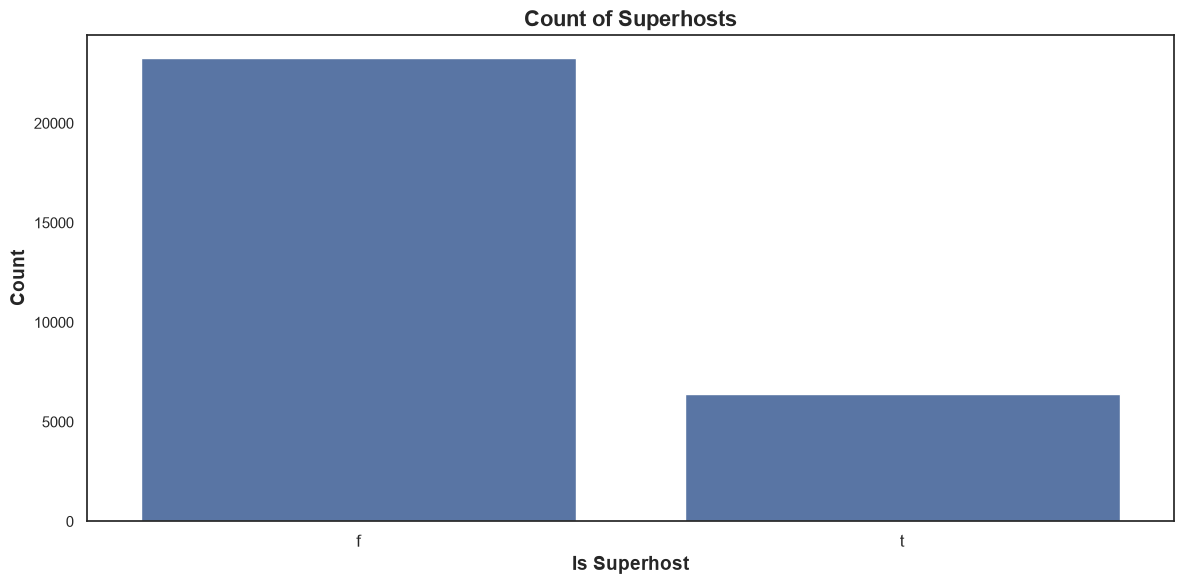

In [179]:
#Distribution of our label host_is_superhost
plt.figure(figsize=(12, 6))
sns.countplot(x='host_is_superhost', data=df)

plt.xlabel('Is Superhost', fontsize=14, fontweight='bold')
plt.ylabel('Count', fontsize=14, fontweight='bold')
plt.title('Count of Superhosts', fontsize=16, fontweight='bold')

plt.xticks(rotation=0, fontsize=12)
plt.tight_layout()
plt.show();

In [180]:
#any columns with urls we remove them to ensure clean data and no noise
url_colnames = [i for i in list(df.columns) if '_url' in i]
url_colnames


['listing_url',
 'picture_url',
 'host_url',
 'host_profile_url',
 'host_picture_url']

In [181]:
#remove columns with url's: have no predictve value
#rememebr to include inplace=true to make the change permanent to the dataframe
#axis=1 since we are removing column features not row indexes/
df.drop(url_colnames,axis=1,inplace=True)


## Exploratory Data Analysis: Finding the best features and cleaning the Data: Removing null values, handling outliers

In [182]:
# The number of unique values for each column
df.nunique()

id                                              30234
scrape_id                                           1
last_scraped                                        3
source                                              2
name                                            28726
                                                ...  
calculated_host_listings_count                     68
calculated_host_listings_count_entire_homes        52
calculated_host_listings_count_private_rooms       40
calculated_host_listings_count_shared_rooms         9
reviews_per_month                                 846
Length: 73, dtype: int64

In [183]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 30234 entries, 0 to 30233
Data columns (total 73 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   id                                            30234 non-null  int64  
 1   scrape_id                                     30234 non-null  int64  
 2   last_scraped                                  30234 non-null  str    
 3   source                                        30234 non-null  str    
 4   name                                          30233 non-null  str    
 5   description                                   28995 non-null  str    
 6   host_id                                       30234 non-null  int64  
 7   host_profile_id                               29671 non-null  float64
 8   host_name                                     29671 non-null  str    
 9   hosts_time_as_user_years                      29671 non-null  float64
 1

##So far from the Data we have alot of columns and most of our data is ints and floats, may have good prediction value and possible models to use during the modle selection steps.
Another note: The price column is a string because it has a dollar sign in front of the values, we need to remove them and cst the columns into floats.

Next steps: Checking for missing values.
EDA: PART 2: Data cleaning: missing values, one hot enocidng categorical features, visualizing features, correlation map of features to our label.

In [184]:
#define our label: host_is_superhost
df["host_is_superhost"]
print(df['host_is_superhost'].isnull().sum())
#remove null rows in label column
df = df.dropna(subset=['host_is_superhost']).copy()
print(df['host_is_superhost'].isnull().sum())

563
0


In [185]:
#changing label from t=1, and f = 0
df['host_is_superhost'] = df["host_is_superhost"].replace({'t': 1, 'f': 0}).astype(int)
df['host_is_superhost'].dtype


dtype('int64')

In [186]:
df['price']

0        $105.01
1        $118.50
2         $84.48
3        $195.47
4            NaN
          ...   
30229        NaN
30230    $662.33
30231        NaN
30232    $255.82
30233        NaN
Name: price, Length: 29671, dtype: str

In [187]:
#remove the $sign from the price column
df['price'] = df['price'].replace(r'[\$,]', '', regex=True).astype(float)

In [188]:
#Dropping columns with id/no predicitive value or way to many missing values to serve no prediction value. 
#we remove the amenites and host location columns because of high cardinality. In addition since the listings are nyc based, dont serve enough predictuve values
cols_todrop = [
    'scrape_id', 'last_scraped', 'source', 'name', 'description',
     'host_id', 'host_profile_id',
    'host_name', 'host_about',
    'calendar_last_scraped', 'first_review', 'last_review', 'license',
    'price_quote_checkin_date', 'price_quote_checkout_date', 'price_quote_raw',
    'bathrooms_text', "id","host_location"
]
df.drop(cols_todrop,axis=1,inplace=True)

Reasoning: The columns with urls or is just give informaton about the user and wont have any predictive value to the label. In addition raw text such as a host bio doesnt give much information for the modle to lean from, and is just basic data for the airbnb host website.


In [189]:
print(df.shape)
df.isnull().sum()

(29671, 54)


hosts_time_as_user_years                            0
hosts_time_as_user_months                           0
hosts_time_as_host_years                            0
hosts_time_as_host_months                           0
host_is_superhost                                   0
host_listings_count                                 0
host_has_profile_pic                                0
host_identity_verified                              0
neighbourhood_cleansed                              0
neighbourhood_group_cleansed                        0
latitude                                            0
longitude                                           0
property_type                                       0
room_type                                           0
accommodates                                        0
bathrooms                                        9810
bedrooms                                        11901
beds                                             9212
amenities                   

## Now We will handle replacing the missing values for the remaining columns.
To prevent data leakage it is best to split into training and test datasets so the model doesnt learn from future data

In [190]:
#Gets all the columns with missing values
null_columns_array = df.columns[df.isnull().any()].to_numpy()
null_counts = df[null_columns_array].isnull().sum()
data_type = df[null_columns_array].dtypes
print(null_counts)
print("----------------------------------------------DATA TYPES------------------------------------")
print(data_type)


bathrooms                       9810
bedrooms                       11901
beds                            9212
price                           9848
price_quote_total_price         9849
price_quote_price_per_night     9849
minimum_nights                     6
maximum_nights                     6
minimum_minimum_nights             6
maximum_minimum_nights             6
minimum_maximum_nights             6
maximum_maximum_nights             6
has_availability                 348
estimated_revenue_l365d         9848
review_scores_rating            8197
review_scores_accuracy          8203
review_scores_cleanliness       8197
review_scores_checkin           8205
review_scores_communication     8200
review_scores_location          8206
review_scores_value             8206
reviews_per_month               8197
dtype: int64
----------------------------------------------DATA TYPES------------------------------------
bathrooms                      float64
bedrooms                       float64
be

Since we hae roughly 30k rows the missing values for the columns are around 7-8k which is not bad and not enough to consider dropping the entire column itself if there is good predicitve value. 
During our eda we looked at the distribution of the numeric columns and came to the conclusion that for skewed data its best to use the median to fill the missing values and for symetric/uniform data it's best to use the mean.

However, for catgorical columns it may not be best to use the mode since the missing values accoun for 20% of that columns data which can cause heavy class imbalance. Luckily the has_avalability column is only a smal fraction of our data 348 records out of 30k which is below the 5% threshold so we can safely use the mode to fill the missing values.

For the host_location we can just fill the missing values with an 'unknown' value.


Before filling missing values we should first split into traning nd test to prevent any data leakage from calculating means,medians, and modes.

In [191]:
#change the binary data to numeric
df["host_has_profile_pic"] = df["host_has_profile_pic"].replace({'t': 1, 'f': 0}).astype(int)
df["host_identity_verified"] = df["host_identity_verified"].replace({'t': 1, 'f': 0}).astype(int)
df["has_availability"] = df["has_availability"].replace({'t': 1, 'f': 0})
#has avaliablity has null values so we must fil those first befoe catsing into an int
print(df["host_has_profile_pic"].dtype)
print(df["host_identity_verified"].dtype)



int64
int64


Starting with filing in missing values for the review columns. We need a way for the model to know the differnece ebwteen a 0 meaning this posting simply hasnt been reviewed yet and 0 as a genuine low score. To do this we provide  aflag column to distinguish this.

In [192]:
review_cols = [
    'review_scores_rating', 'review_scores_accuracy', 'review_scores_cleanliness',
    'review_scores_checkin', 'review_scores_communication', 'review_scores_location',
    'review_scores_value', 'reviews_per_month',
]
#we willo add a new column called has_rating and this will be the flag for the model is the number of reviews column is over 0. Hence if an entry has reiews > 0 then a score of 0 i a genuin low score
df['has_rating'] = (df['number_of_reviews'] > 0).astype(int)
#now we can safely fill the columns with 0 this wont cause data leakage before splitting because 0 doesnt serve anything and we flag that 0 means a review wiht no ratings or dat athat was filled
df[review_cols] = df[review_cols].fillna(0)

** Now we need to split into train and test sets to prevent dat leakage when filling in missing values

In [193]:
#copy data to store the label for correlation checks
df = df.drop_duplicates()
y = df['host_is_superhost']
X = df.drop(['host_is_superhost'],axis=1)
label = y_train
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2,random_state=42,stratify=y)

In [194]:
print("X_train Shape: ", X_train.shape)
print("y_train Shape: ", y_train.shape)
print("X_test Shape: ", X_test.shape)
print("y_test Shape: ", y_test.shape)
print("---------------------------------NULL COUNT FOR EACH rewview column in X_train---------------------------")
X_train[review_cols].isnull().sum()

X_train Shape:  (23568, 54)
y_train Shape:  (23568,)
X_test Shape:  (5893, 54)
y_test Shape:  (5893,)
---------------------------------NULL COUNT FOR EACH rewview column in X_train---------------------------


review_scores_rating           0
review_scores_accuracy         0
review_scores_cleanliness      0
review_scores_checkin          0
review_scores_communication    0
review_scores_location         0
review_scores_value            0
reviews_per_month              0
dtype: int64

Now we will fill in the missing values for price columns. Now for filling in missing values of the price clumn we saw earlier tha the price distrubution is skewed hence we will use the median to fill in the missing values.

But we have to flag the rows that didnt have a price value to let the model distinguish a missing value between an actual value

In [195]:
X_train['price_was_missing'] = X_train['price'].isnull().astype(int)

X_train['price'] = X_train.groupby(['neighbourhood_group_cleansed', 'room_type'])['price'].transform(lambda s: s.fillna(s.median()))
#Do the same for test dataset
X_test['price'] = X_test.groupby(['neighbourhood_group_cleansed', 'room_type'])['price'].transform(lambda s: s.fillna(s.median()))
X_train['price'] = X_train['price'].fillna(X_train['price'].median())
#Do the same for test dataset
X_test['price'] = X_test['price'].fillna(X_test['price'].median())
price_cols = ['price_quote_total_price', 'price_quote_price_per_night', 'estimated_revenue_l365d']
X_train[price_cols] = X_train[price_cols].fillna(X_train[null_columns_array].mode().iloc[0])
#Do the same for test dataset
X_test[price_cols] = X_test[price_cols].fillna(X_test[null_columns_array].mode().iloc[0])

In [196]:
print("Price null count X_train: " , X_train['price'].isnull().sum())
print()
print("Price null count X_test: " , X_test['price'].isnull().sum())
print()
print("Price columns null count X_train: ", X_train[price_cols].isnull().sum())
print()
print("Price columns null count X_test: ", X_test[price_cols].isnull().sum())


Price null count X_train:  0

Price null count X_test:  0

Price columns null count X_train:  price_quote_total_price        0
price_quote_price_per_night    0
estimated_revenue_l365d        0
dtype: int64

Price columns null count X_test:  price_quote_total_price        0
price_quote_price_per_night    0
estimated_revenue_l365d        0
dtype: int64


In [197]:
X_train["host_has_profile_pic"].value_counts()
X_train["host_identity_verified"].value_counts()

host_identity_verified
1    23268
0      300
Name: count, dtype: int64

In [198]:
X_train.head()

,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,...,review_scores_communication,review_scores_location,review_scores_value,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month,has_rating,price_was_missing
8144,13.0,6.0,13.0,6.0,10.0,1,1,Harlem,Manhattan,40.805080,...,4.85,4.56,4.45,10,10,0,0,0.63,1,0
6580,10.0,4.0,10.0,1.0,1.0,1,1,South Slope,Brooklyn,40.666070,...,5.00,4.67,4.67,1,1,0,0,0.03,1,1
25390,9.0,4.0,0.0,11.0,1.0,1,1,Jamaica,Queens,40.702520,...,0.00,0.00,0.00,1,0,0,1,0.00,0,0
9399,7.0,11.0,7.0,9.0,4.0,1,1,Bedford-Stuyvesant,Brooklyn,40.677370,...,5.00,5.00,4.56,4,3,1,0,0.12,1,0
28416,0.0,5.0,0.0,4.0,17.0,1,1,Theater District,Manhattan,40.759687,...,0.00,0.00,0.00,17,0,15,0,0.00,0,0


In [199]:
X_train["amenities"]

8144     ["Hair dryer", "Essentials", "Hangers", "Iron"...
6580     ["Bathtub", "Shampoo", "Wifi", "Washer", "Ethe...
25390    ["Essentials", "Coffee maker: Keurig coffee ma...
9399     ["Hair dryer", "Essentials", "Smart lock", "Ha...
28416    ["Hair dryer", "Essentials", "Dedicated worksp...
                               ...                        
25648    ["Washer", "TV", "Dedicated workspace", "Exter...
22266    ["Carbon monoxide alarm", "Essentials", "Exerc...
25501    ["Hair dryer", "Dedicated workspace", "Dining ...
61       ["Hair dryer", "Essentials", "27 inch HDTV wit...
28798    ["Hair dryer", "Dedicated workspace", "Hot wat...
Name: amenities, Length: 23568, dtype: str

In [200]:
#filling in the remaining columns wiht the median, since these values are skewed.
low_missing_numeric = [
    'minimum_nights', 'maximum_nights', 'minimum_minimum_nights',
    'maximum_minimum_nights', 'minimum_maximum_nights', 'maximum_maximum_nights',
]
X_train[low_missing_numeric] = X_train[low_missing_numeric].fillna(X_train[low_missing_numeric].median().iloc[0])
X_test[low_missing_numeric] = X_train[low_missing_numeric].fillna(X_train[low_missing_numeric].median().iloc[0])
X_train[low_missing_numeric]

,minimum_nights,maximum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights
8144,3.0,28.0,3.0,4.0,28.0,28.0
6580,30.0,1125.0,30.0,30.0,1125.0,1125.0
25390,30.0,365.0,30.0,30.0,365.0,365.0
9399,30.0,1125.0,30.0,30.0,1125.0,1125.0
28416,1.0,365.0,1.0,4.0,1.0,365.0
...,...,...,...,...,...,...
25648,30.0,30.0,30.0,30.0,30.0,30.0
22266,30.0,365.0,30.0,30.0,365.0,365.0
25501,1.0,21.0,1.0,1.0,21.0,21.0
61,30.0,250.0,30.0,30.0,250.0,250.0


In [201]:
X_train.isnull().sum()
X_train['has_availability'].value_counts()

has_availability
1    23189
0      113
Name: count, dtype: int64

In [202]:
X_train['has_availability'] = X_train['has_availability'].fillna(X_train['has_availability'].mode()[0])
X_train['has_availability'] = X_train['has_availability'].astype(int)

X_test['has_availability'] = X_test['has_availability'].fillna(X_test['has_availability'].mode()[0])
X_test['has_availability'] = X_test['has_availability'].astype(int)
X_train['has_availability'].isnull().sum()
X_train['has_availability'].value_counts()

print("X_train null count: ", X_train['has_availability'].isnull().sum())
print("X_test null count: ", X_test['has_availability'].isnull().sum())
print("X_train value count: ", X_train['has_availability'].value_counts())
print("X_test value count: ", X_test['has_availability'].value_counts())


print(f'Data type of has_avaliablity after imputing X_train {X_train['has_availability'].dtype}, {X_test['has_availability'].dtype}')

X_train null count:  0
X_test null count:  0
X_train value count:  has_availability
1    23455
0      113
Name: count, dtype: int64
X_test value count:  has_availability
1    5870
0      23
Name: count, dtype: int64
Data type of has_avaliablity after imputing X_train int64, int64


In [203]:
X_train.isnull().sum()

hosts_time_as_user_years                           0
hosts_time_as_user_months                          0
hosts_time_as_host_years                           0
hosts_time_as_host_months                          0
host_listings_count                                0
host_has_profile_pic                               0
host_identity_verified                             0
neighbourhood_cleansed                             0
neighbourhood_group_cleansed                       0
latitude                                           0
longitude                                          0
property_type                                      0
room_type                                          0
accommodates                                       0
bathrooms                                       7838
bedrooms                                        9480
beds                                            7342
amenities                                          0
price                                         

In [204]:
#for bedrooms, bathrooms, and beds we dont want to just fill with the median for their colunmns that would couase inconsstency in the data
#since there are different room types with different number of bedrooms, bathrooms, and beds
#instead we group each column wiht the room type and fill the missing values with the median for each room type
#this provides more accuracy, for example a private room type having 10 rooms wouldnt make sense so we join on room type and just use the median of that group.
#Groups rows by room_type, then within each group fills that group's NaNs with that group's own median — so Private rooms get filled with the Private-room median, Entire homes with the Entire-home median, etc., instead of one global median for everyone.
#Then also have
cols = ['bedrooms', 'bathrooms', 'beds']

# Flag to still give model context on what was a missing value, since median still blurs over real variation.
X_train[[f'{c}_was_missing' for c in cols]] = X_train[cols].isnull().astype(int)
X_test[[f'{c}_was_missing' for c in cols]] = X_test[cols].isnull().astype(int)
X_train[cols] = X_train.groupby('room_type')[cols].transform(lambda s: s.fillna(s.median()))
X_test[cols] = X_test.groupby('room_type')[cols].transform(lambda s: s.fillna(s.median()))
X_train[cols] = X_train[cols].fillna(X_train[cols].median())
X_test[cols] = X_test[cols].fillna(X_test[cols].median())

print("Null values after X_train: ", X_train[cols].isnull().sum())
print("Null values after X_test: ", X_test[cols].isnull().sum())

Null values after X_train:  bedrooms     0
bathrooms    0
beds         0
dtype: int64
Null values after X_test:  bedrooms     0
bathrooms    0
beds         0
dtype: int64


## Step 3: All columns are now cleaned and there are no null values. Now we will perform feature selection using correlation matrices to our label host_is_superhost.

We will make the correlation matrix for the numeric variables and use mutual information to determine suitable features for our label.


First lest plot the numeric fetaures aganist the label to see if there is any linearity since the correlation coeficcent is best if data is linear.

In [205]:
def plot_num_target(x_train,num_feature,y_train):
    # # 1. Break the numerical feature into 5-10 equal-width bins
    # X_train['num_bins'] = pd.cut(df[num_feature], bins=10)
    
    # # 2. Plot the mean of the boolean feature for each bin
    # plt.figure(figsize=(10, 5))
    # sns.barplot(x=num_feature, y=target, data=X_train, color='green', errorbar=None)
    
    # plt.xticks(rotation=45)
    # plt.ylabel("Proportion of True / 1")
    # plt.title("Checking Linearity via Binned Means")
    # plt.tight_layout()
    # plt.show()
    plt.figure(figsize=(3,3))
    sns.scatterplot(x=X_train[num_feature],y=y_train, color="blue")
    plt.tight_layout()
    plt.show()


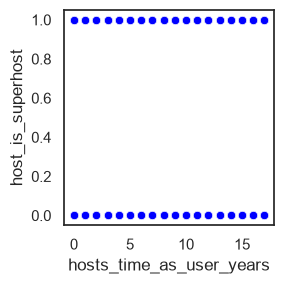

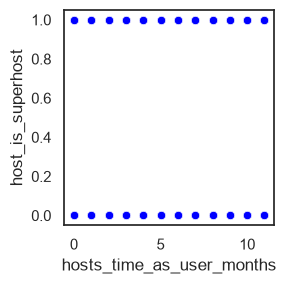

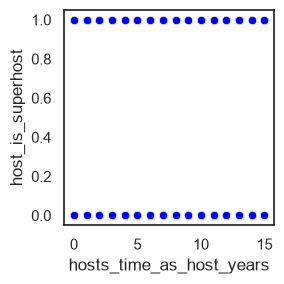

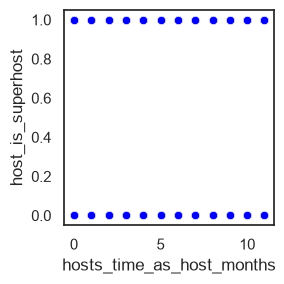

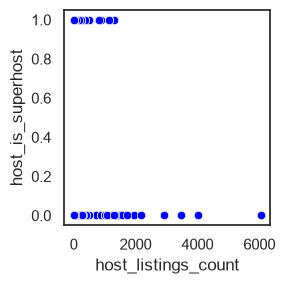

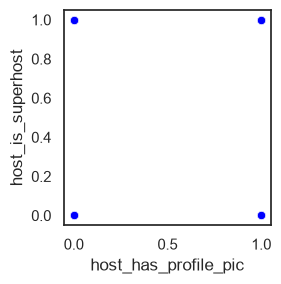

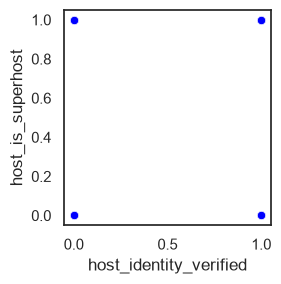

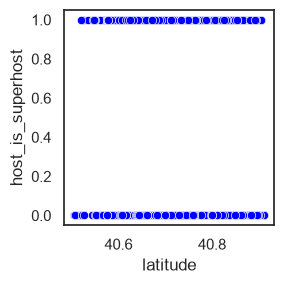

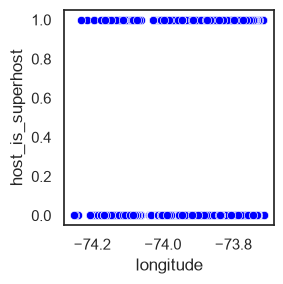

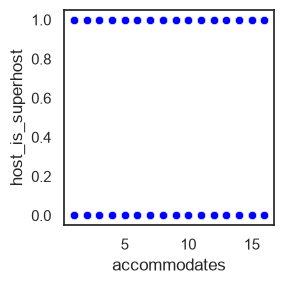

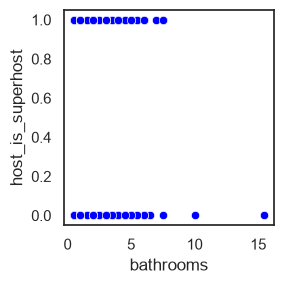

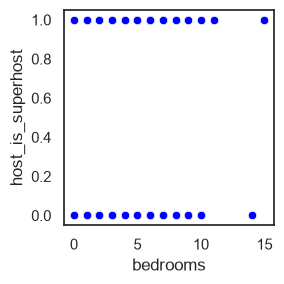

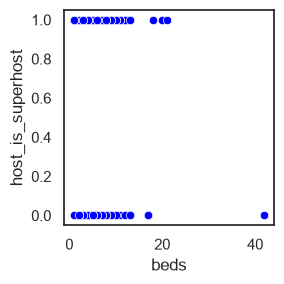

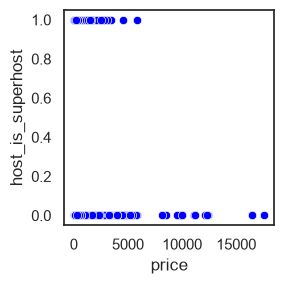

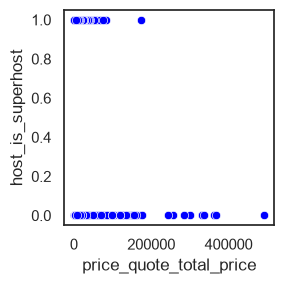

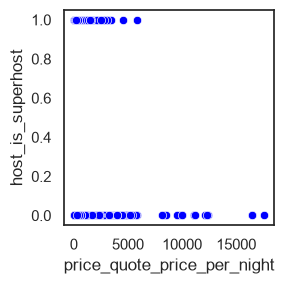

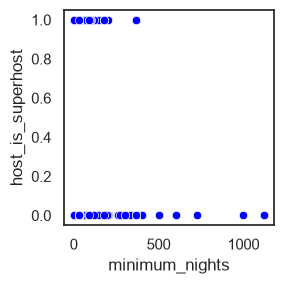

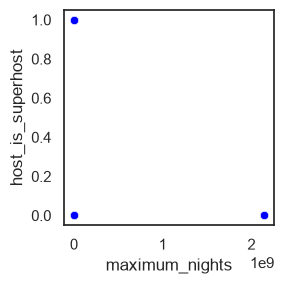

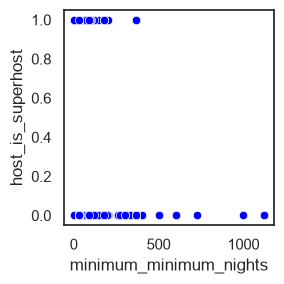

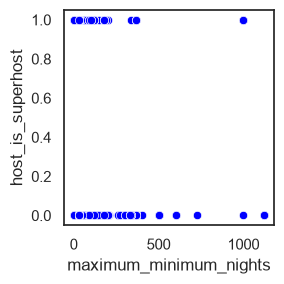

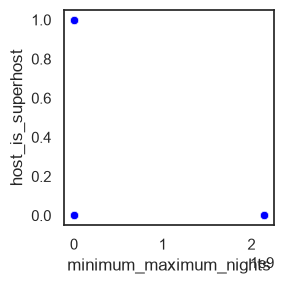

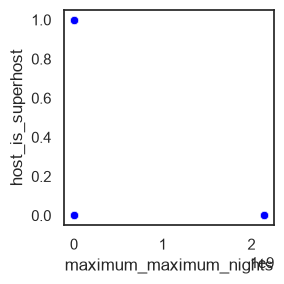

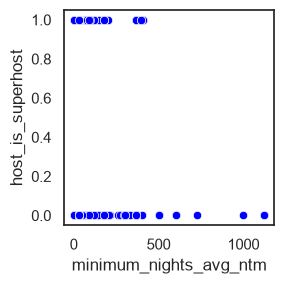

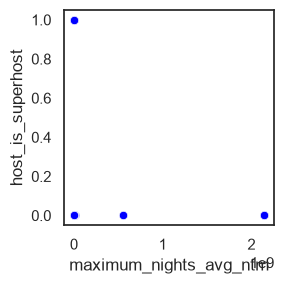

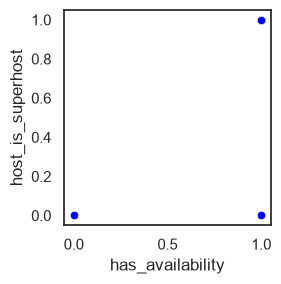

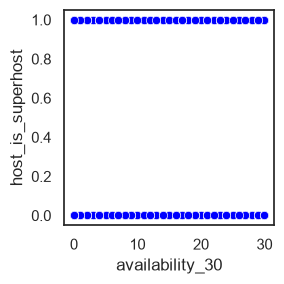

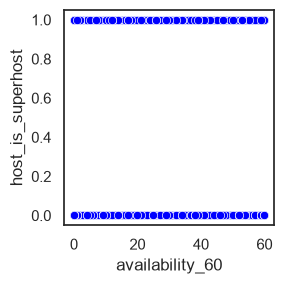

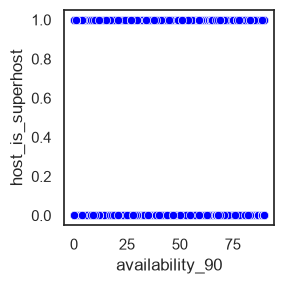

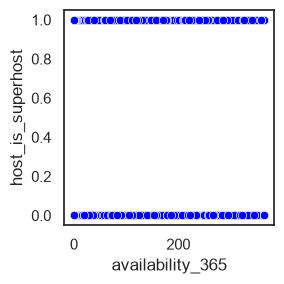

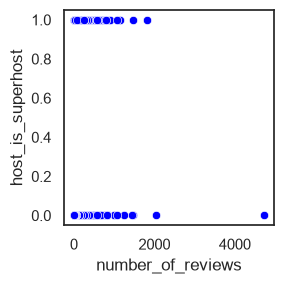

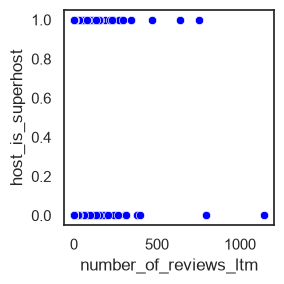

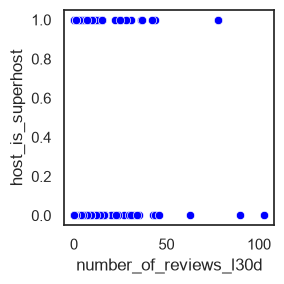

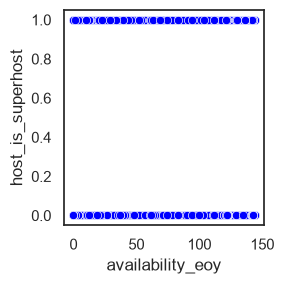

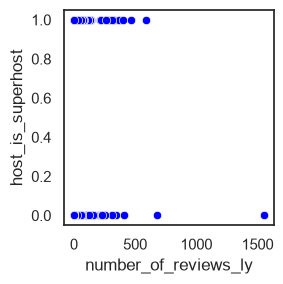

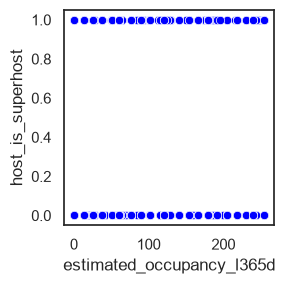

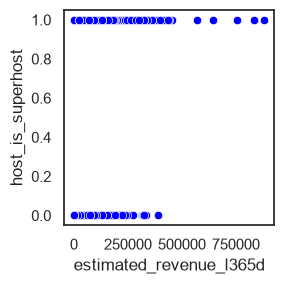

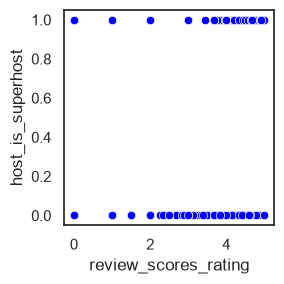

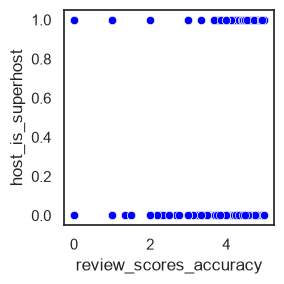

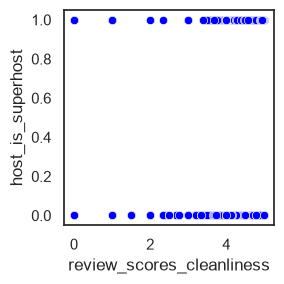

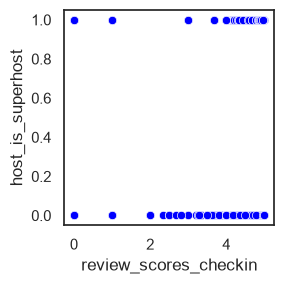

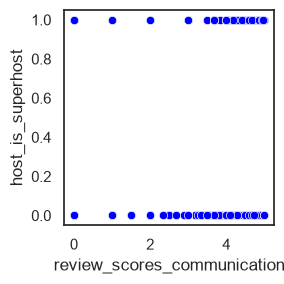

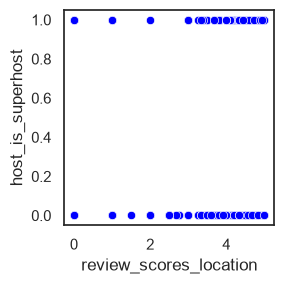

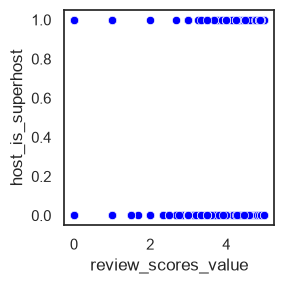

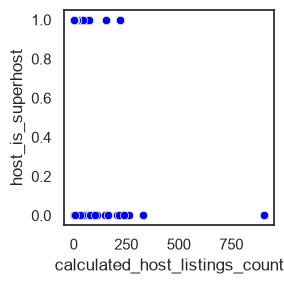

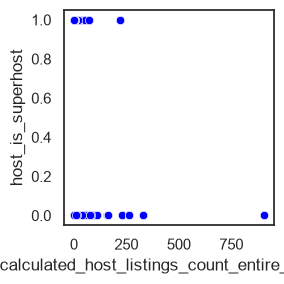

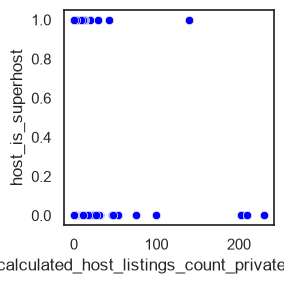

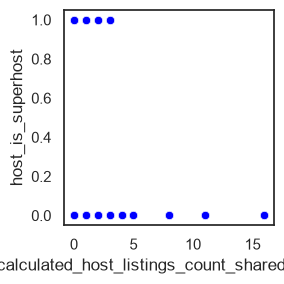

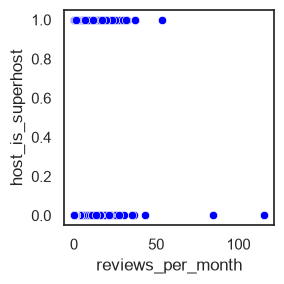

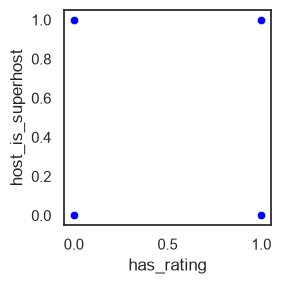

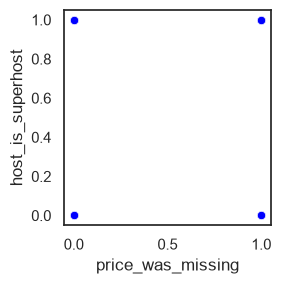

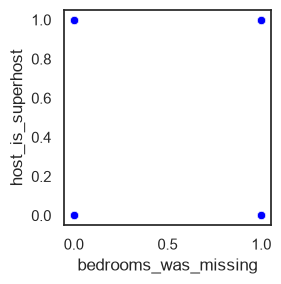

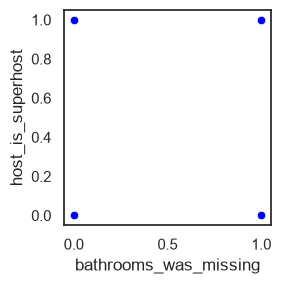

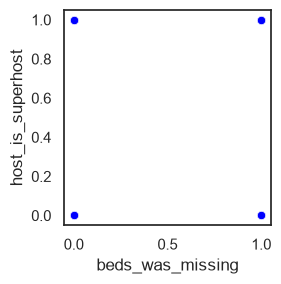

In [206]:
numeric_features = list(X_train.select_dtypes(include=['number']).columns)[:]
for num in numeric_features:
     plot_num_target(X_train,num,y_train)


Analysis: The data is skewed and symetric no linearity really.

In [207]:
#store categorical features to perform a mutual information to find predictive value with label, and store numerical features to perform correlation
categorical_features = list(X_train.select_dtypes(include=['str']).columns)
X_train['host_is_superhost'] = label
corr = X_train[numeric_features + ['host_is_superhost']].corr()["host_is_superhost"].sort_values(ascending=False)
corr


host_is_superhost                               1.000000
estimated_occupancy_l365d                       0.509502
estimated_revenue_l365d                         0.346454
number_of_reviews                               0.228292
review_scores_cleanliness                       0.223285
number_of_reviews_ltm                           0.221511
review_scores_rating                            0.219875
review_scores_value                             0.218298
review_scores_accuracy                          0.214775
review_scores_communication                     0.213320
number_of_reviews_ly                            0.212123
reviews_per_month                               0.210634
review_scores_checkin                           0.209922
review_scores_location                          0.203084
has_rating                                      0.194987
number_of_reviews_l30d                          0.165428
availability_365                                0.107963
longitude                      

Based on the correlation estimated_occupany_l356d has a high correlation with the label. However now the question is is that data immediately available, if so its a good feature to consider. We also have alot of features where they ar every similar such as review scores.

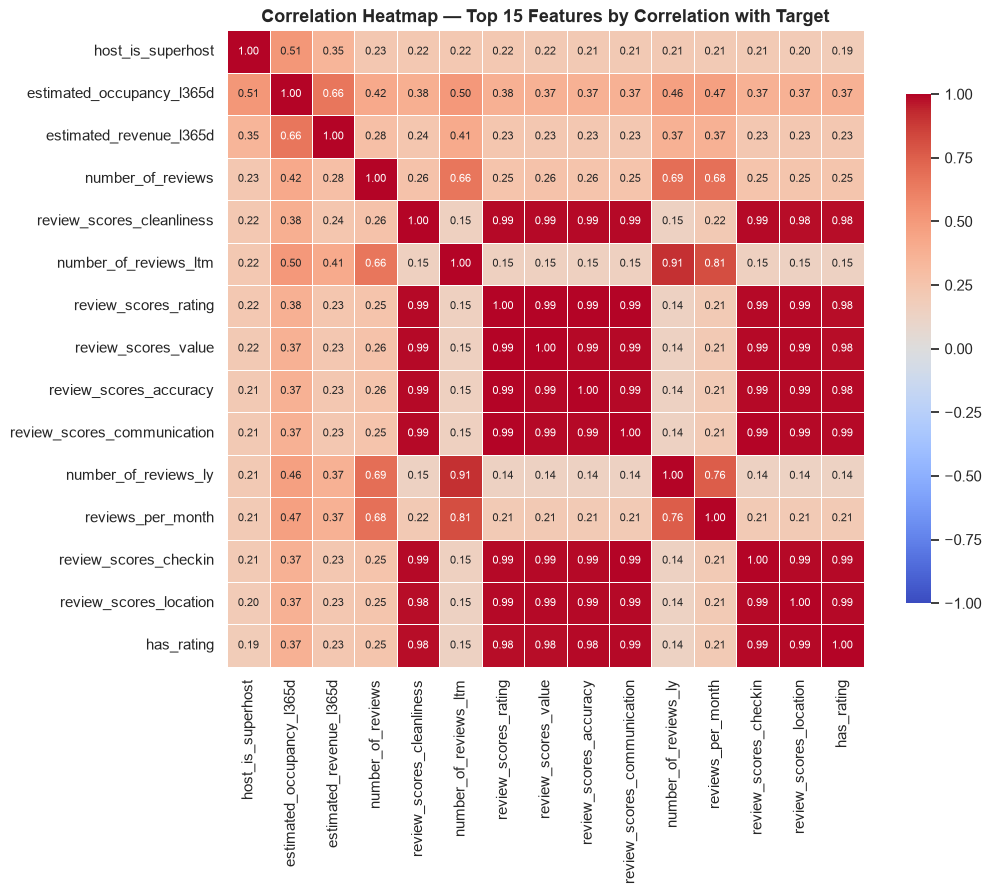

In [208]:

sns.set_theme(style="white")


# Top 15 features by correlation with target
top15_features = corr.head(15).index.tolist()

corr_matrix = X_train[top15_features].corr()

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    square=True,
    linewidths=0.5,
    annot=True, fmt='.2f',  
    annot_kws={'size': 8},
    cbar_kws={'shrink': 0.8},
    ax=ax
)
ax.set_title('Correlation Heatmap — Top 15 Features by Correlation with Target', fontsize=13, fontweight='bold')
plt.tight_layout()

Analysis: Estimated revenue and estimated occupancy are highly correlated may be best to drop one to reduce redundancy. The review features are all highly collinear with each other best to only consider one of them as a feature. Now let's see how strong the categorical variables are using mutual information.

** Mutual Information: Tells us the amount of reduction in uncertatninty that one variable provides to another.
We will first get the mutual information between each feature and the target then a chart of the mutual information ebtwene features to idenitfy any redundancies in the features.

If two features have high mutual info adds redundancy so we consider dropping one.

possible featurs ot use: estimated_occupancy_l365d, estimated_revenue_365d, review_scores_rating


In [209]:
#Extract amenites column to perform exploration on the values later some amenties could have good predictive value
X_train[categorical_features].nunique()
ameniites_save = categorical_features[4]
categorical_features.remove("amenities")
objects = X_train.select_dtypes(include=['object']).columns.tolist()
X_train[objects].nunique()
categorical_features

/var/folders/9r/_kkr4w992wqc97dbjnm2y94h0000gn/T/ipykernel_4561/4083819401.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  objects = X_train.select_dtypes(include=['object']).columns.tolist()


['neighbourhood_cleansed',
 'neighbourhood_group_cleansed',
 'property_type',
 'room_type']

Columns with high cardinality we can drop like host_location which wont have much meaning since all the listings are nyc based, also ammenities has an extremely high cardinality for now we will drop column then circle back if amenities has any predictive power.


In [211]:
X_train.drop(["host_is_superhost"],axis=1,inplace=True)

In [214]:
print(X_train.shape)
print(label.shape)

(23568, 58)
(23568,)


In [215]:
#Create a sperate dataframe ot tets the mutual information
def calc_mutual_info(categorical_features,label):
    X_mi = X_train[categorical_features].copy()
    y_mi = label
    
    # Encode each categorical feature independently: since mutual information requires numbers
    for column in X_mi.columns:
        encoder = LabelEncoder()
        X_mi[column] = encoder.fit_transform(X_mi[column].astype(str))
    
    mi_scores = mutual_info_classif(
        X_mi,
        y_mi,
        discrete_features=True,
        random_state=42
    )
    mi_results = pd.DataFrame({
    'feature': X_mi.columns,
    'mutual_information': mi_scores
    })

    mi_results = mi_results.sort_values(
        by='mutual_information',
        ascending=False
    )

    return mi_results


calc_mutual_info(categorical_features,label)

,feature,mutual_information
0,neighbourhood_cleansed,0.022544
2,property_type,0.013846
1,neighbourhood_group_cleansed,0.004002
3,room_type,0.003286


In [218]:
#Mutual information for the numerical data
def calc_mutual_info_num(numerical_features,label):
    X_mi = X_train[numerical_features].copy()
    y_mi = label
    
    mi_scores = mutual_info_classif(
        X_mi,
        y_mi,
        discrete_features=False,
        random_state=42
    )
    mi_results = pd.DataFrame({
    'feature': X_mi.columns,
    'mutual_information': mi_scores
    })

    mi_results = mi_results.sort_values(
        by='mutual_information',
        ascending=False
    )
    return mi_results

calc_mutual_info_num(numeric_features,label)

,feature,mutual_information
34,estimated_occupancy_l365d,0.122662
30,number_of_reviews_ltm,0.120304
33,number_of_reviews_ly,0.106775
4,host_listings_count,0.101632
35,estimated_revenue_l365d,0.097952
43,calculated_host_listings_count,0.094438
47,reviews_per_month,0.080192
28,availability_365,0.072821
44,calculated_host_listings_count_entire_homes,0.071155
14,price_quote_total_price,0.064708


## Findings
- For categorical features the property type and neighborhood cleansed have the most mutual information with the label although they arent very high but oculd offer some predictive value when used together.

- For the numerical features the data the mutual information is similar to the correlation scores indicating these features may have a good predictive value with the label

- Next Steps: Feature Engineer the ameniites column and see if any of the amenities have any type of predictve value with the label

In [223]:
label

8144     1
6580     0
25390    0
9399     0
28416    0
        ..
25648    0
22266    0
25501    1
61       1
28798    0
Name: host_is_superhost, Length: 23568, dtype: int64

In [225]:
"""
Amenities Feature Engineering
================================
`amenities` is stored as a stringified list, e.g.
'["Wifi", "Kitchen", "Free parking on premises", "Self check-in"]'
This extracts (1) a simple amenity count, and (2) binary flags for the
individual amenities most associated with superhost status, rather than
guessing which ones matter.
"""
import ast
from collections import Counter


#Parse the stringifed list inti actual python list
def parse_amenities(raw):
    try:
        return ast.literal_eval(raw)
    except (ValueError, SyntaxError):
        return []


#1. parse each entry to turn into python list
amenities_test = X_train.copy()
amenities_test['amenities_list'] = amenities_test['amenities'].apply(parse_amenities)


# 2. Simple count feature — often predictive on its own (more amenities
#    can reflect a more invested/thorough host)

amenities_test['amenities_count'] = amenities_test['amenities_list'].apply(len)

# 3. Find which individual amenities actually carry signal, rather than
#    hand-picking a guessed list. Only consider amenities common enough
#    to matter (present in at least 1% of listings) to avoid noise from
#    rare/one-off amenity strings (free-text entries create huge
#    cardinality — e.g. "Sony 50" HDTV" vs "TV").

all_amenities = Counter(a for lst in amenities_test['amenities_list'] for a in lst)
min_count = int(len(df) * 0.01)
common_amenities = [a for a, cnt in all_amenities.items() if cnt >= min_count]
print(f"{len(common_amenities)} amenities appear in at least 1% of listings "
      f"(out of {len(all_amenities)} unique raw amenity strings)")

# # ---------------------------------------------------------------------
# # 4. Build a binary flag per common amenity, then rank by correlation
# #    with the label.

amenity_flags = pd.DataFrame(
    {a: amenities_test['amenities_list'].apply(lambda lst, a=a: int(a in lst)) for a in common_amenities},
    index=amenities_test.index
)

amenity_corr = amenity_flags.apply(lambda col: col.corr(label))
amenity_corr = amenity_corr.sort_values(key=abs, ascending=False)

print("\nTop 20 amenities by correlation with host_is_superhost:")
print(amenity_corr.head(50))

print("\nBottom 20 (weakest/negative signal):")
print(amenity_corr.tail(20))

# ---------------------------------------------------------------------
# 5. Keep only the amenities with real signal as engineered features
#    (threshold is a judgment call — 0.03 here is a reasonable floor
#    given the top overall feature correlations were ~0.2-0.5)
# ---------------------------------------------------------------------
#signal_threshold = 0.20



    # engineered_amenity_cols = ['amenities_count'] + \
#     ['amenity_' + a.lower().replace(' ', '_').replace('/', '_').replace('"', '') for a in top_amenities]

# print("\nEngineered amenity columns added to df:")
# print(engineered_amenity_cols)
# print(amenity_flags.dtypes.head())
# df.shape

144 amenities appear in at least 1% of listings (out of 5172 unique raw amenity strings)

Top 20 amenities by correlation with host_is_superhost:
Free street parking                      0.252329
Cleaning products                        0.237417
Microwave                                0.226424
Shower gel                               0.223226
Dishes and silverware                    0.220266
Dining table                             0.215704
Laundromat nearby                        0.208680
Coffee                                   0.206994
Conditioner                              0.203388
Hot water                                0.199114
Freezer                                  0.197545
Bed linens                               0.196422
Exterior security cameras on property    0.193739
Wine glasses                             0.187588
Room-darkening shades                    0.187482
Hot water kettle                         0.187272
Body soap                                0.187149
Cook

## Findings
- Free street parking, cleaning products, microwave and shower gel seem to have good predicive value for the label we will ow feature enigneer these amenities into our training data. 

In [226]:
top_amenities = ["Free street parking","Cleaning products","Microwave"]
# amenity_corr[amenity_corr.abs() > signal_threshold].index.tolist()
# print(f"\n{len(top_amenities)} amenities pass the |r| > {signal_threshold} threshold")

for a in top_amenities:
    col_name = 'amenity_' + a.lower().replace(' ', '_').replace('/', '_').replace('"', '')
    X_train[col_name] = amenity_flags[a]

In [233]:
X_train.head(20)


,hosts_time_as_user_years,hosts_time_as_user_months,hosts_time_as_host_years,hosts_time_as_host_months,host_listings_count,host_has_profile_pic,host_identity_verified,neighbourhood_cleansed,neighbourhood_group_cleansed,latitude,...,calculated_host_listings_count_shared_rooms,reviews_per_month,has_rating,price_was_missing,bedrooms_was_missing,bathrooms_was_missing,beds_was_missing,amenity_free_street_parking,amenity_cleaning_products,amenity_microwave
8144,13.0,6.0,13.0,6.0,10.0,1,1,Harlem,Manhattan,40.805080,...,0,0.63,1,0,0,0,0,0,0,1
6580,10.0,4.0,10.0,1.0,1.0,1,1,South Slope,Brooklyn,40.666070,...,0,0.03,1,1,0,1,1,1,0,0
25390,9.0,4.0,0.0,11.0,1.0,1,1,Jamaica,Queens,40.702520,...,1,0.00,0,0,0,0,0,1,0,1
9399,7.0,11.0,7.0,9.0,4.0,1,1,Bedford-Stuyvesant,Brooklyn,40.677370,...,0,0.12,1,0,0,0,0,1,0,1
28416,0.0,5.0,0.0,4.0,17.0,1,1,Theater District,Manhattan,40.759687,...,0,0.00,0,0,0,0,0,0,0,0
21689,2.0,4.0,1.0,11.0,1.0,1,1,Mariners Harbor,Staten Island,40.631910,...,0,0.00,0,1,0,0,0,0,0,0
12461,4.0,10.0,4.0,10.0,2.0,1,1,Prospect-Lefferts Gardens,Brooklyn,40.657460,...,0,0.34,1,0,1,0,0,0,0,0
11484,6.0,2.0,6.0,2.0,50.0,1,1,Midtown,Manhattan,40.746160,...,0,0.60,1,0,1,0,0,0,0,1
22824,4.0,5.0,4.0,5.0,6049.0,0,1,Midtown,Manhattan,40.749350,...,0,0.00,0,0,0,0,0,0,1,0
8712,8.0,2.0,6.0,11.0,6.0,1,1,Far Rockaway,Queens,40.605630,...,0,0.14,1,1,0,0,0,1,0,1


In [78]:
def plot_roc(y_test, X_test, model, model_name):
    try:
        AUC = roc_auc_score(y_test, model.predict_proba(X_test)[:,1])
        fpr, tpr, thresholds = roc_curve(y_test, model.predict_proba(X_test)[:,1])

        plt.figure()
        lw = 2
        plt.plot(fpr, tpr, color='darkorange', lw=lw, label='ROC curve (area = %0.2f)' % AUC)
        plt.plot([0, 1], [0, 1], color='navy', lw=lw, linestyle='--')
        plt.xlim([0.0, 1.0])
        plt.ylim([0.0, 1.05])
        plt.xlabel('False Positive Rate')
        plt.ylabel('True Positive Rate')
        plt.title('Receiver operating characteristic {}'.format(model_name))
        plt.legend(loc="lower right");
    except:
        None

In [79]:
def train_predict(classifier, X, y):
    #train_test_split
    X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=33)
    #fit_classifier
    classifier.fit(X_train, y_train)
    y_predictions = classifier.predict(X_test)
    print("Accuracy")
    #train_test_accuracy
    print ("Train Accuracy : {}".format(accuracy_score(y_train, classifier.predict(X_train))))
    print ("Test Accuracy  : {}".format(accuracy_score(y_test, y_predictions)))
    print("")
    print("Confusion Matrix")
    #confusion_matrix
    tn, fp, fn, tp = confusion_matrix(y_test, y_predictions).ravel()
    print("True Negative: {}".format(tn))
    print("True Positive: {}".format(tp))
    print("False Negative: {}".format(fn))
    print("False Positive: {}".format(fp))
    print("")
    #classification_report
    print("Classification Report")
    print(classification_report(y_test, y_predictions, target_names=['Not_Superhost', 'Superhost']))
    #roc_curve
    print("")
    plot_roc(y_test, X_test, model=classifier, model_name="classifier")
    return None